In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

Reading dataset

In [2]:
dataset_path = "/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training"

CLASSES = [
    "Apple Golden 1",
    "Banana 1",
    "Blackberrie 1",
    "Cantaloupe 1",
    "Cherry 1"
]

IMG_SIZE = 64

In [3]:
images = []
labels = []

for label, class_name in enumerate(CLASSES):
    class_path = os.path.join(dataset_path, class_name)
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        images.append(img)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Total images:", images.shape)
print("Total labels:", labels.shape)

Total images: (2404, 64, 64, 3)
Total labels: (2404,)


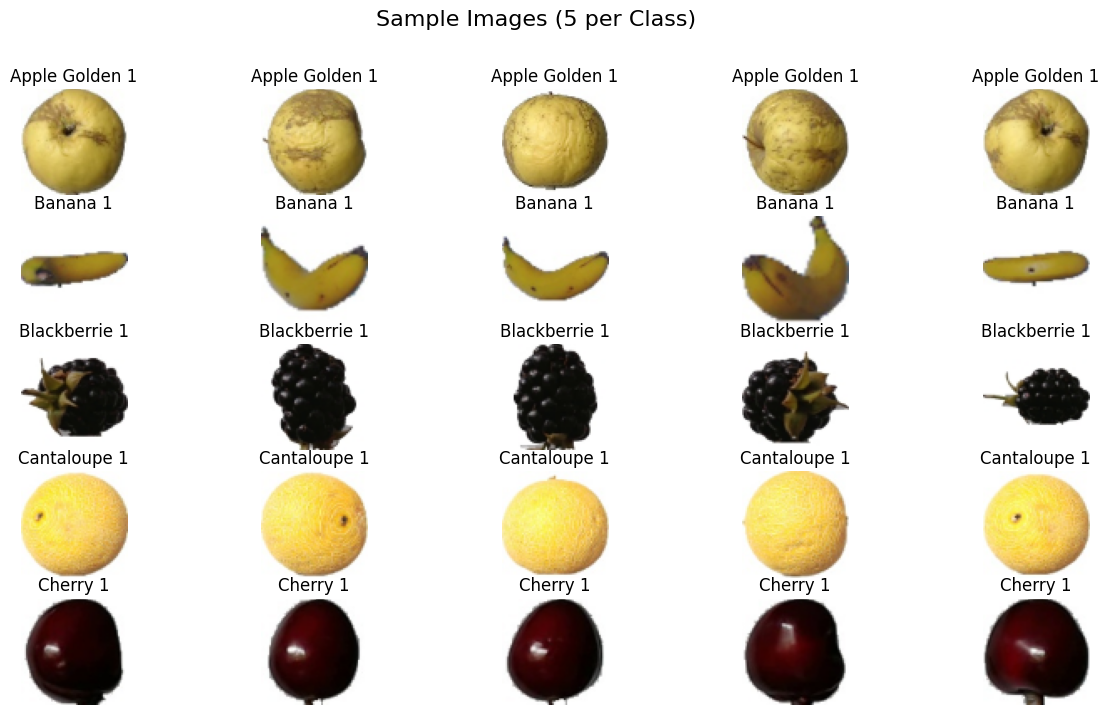

In [4]:
plt.figure(figsize=(15,8))
img_index = 1

for class_id, class_name in enumerate(CLASSES):
    class_images = images[labels == class_id][:5]
    
    for img in class_images:
        plt.subplot(len(CLASSES), 5, img_index)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(class_name)
        plt.axis("off")
        img_index += 1

plt.suptitle("Sample Images (5 per Class)", fontsize=16)
plt.show()


Normalization

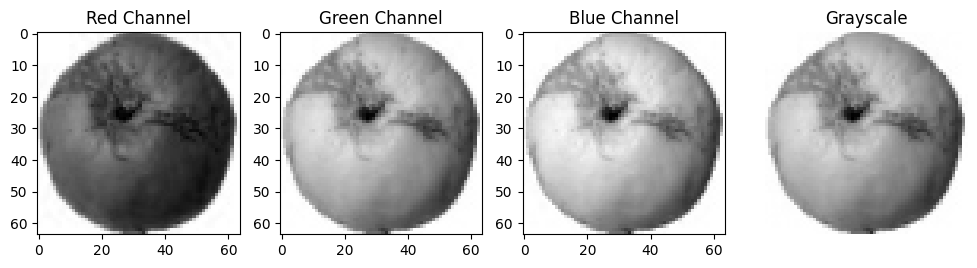

In [5]:
sample_img = images[0]

R, G, B = cv2.split(sample_img)
gray_sample = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(R, cmap='gray'); plt.title("Red Channel")
plt.subplot(1,4,2); plt.imshow(G, cmap='gray'); plt.title("Green Channel")
plt.subplot(1,4,3); plt.imshow(B, cmap='gray'); plt.title("Blue Channel")
plt.subplot(1,4,4); plt.imshow(gray_sample, cmap='gray'); plt.title("Grayscale")
plt.axis("off")
plt.show()


In [6]:
gray_images = []

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray)

gray_images = np.array(gray_images)


In [7]:
normalized_images = []

for gray_image in gray_images:
    min_val = np.min(gray_image)
    max_val = np.max(gray_image)
    
    norm_image = (gray_image - min_val) / (max_val - min_val)
    normalized_images.append(norm_image)

normalized_images = np.array(normalized_images)


In [8]:
gray_uint8 = (normalized_images * 255).astype(np.uint8)


In [9]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_images = []

for gray in gray_uint8:
    enhanced = clahe.apply(gray)
    clahe_images.append(enhanced)

clahe_images = np.array(clahe_images)


In [10]:
smoothed_images = []

for img in clahe_images:
    smooth = cv2.GaussianBlur(img, (3,3), 0)
    smoothed_images.append(smooth)

smoothed_images = np.array(smoothed_images)


In [11]:
sobel_features = []
laplacian_features = []

for img in smoothed_images:
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobelx**2 + sobely**2)
    
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    
    sobel_features.append(sobel.flatten())
    laplacian_features.append(laplacian.flatten())

sobel_features = np.array(sobel_features)
laplacian_features = np.array(laplacian_features)


In [12]:
sharpened_features = []

kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

for img in smoothed_images:
    sharp = cv2.filter2D(img, -1, kernel)
    sharpened_features.append(sharp.flatten())

sharpened_features = np.array(sharpened_features)


In [13]:
binary_features = []

for img in smoothed_images:
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    binary_features.append(binary.flatten())

binary_features = np.array(binary_features)


In [14]:
X = np.hstack([
    sobel_features,
    laplacian_features
])

y = labels

print("Final feature vector shape:", X.shape)


Final feature vector shape: (2404, 8192)


In [15]:


X_tarin, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))


NameError: name 'X_train' is not defined

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()


In [ ]:
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
y_score = model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASSES[i]} (AUC={roc_auc:.2f})")

plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_test)

print("K-Means clustering completed")


In [ ]:
cm_kmeans = confusion_matrix(y_test, clusters)

plt.figure(figsize=(6,5))
plt.imshow(cm_kmeans, cmap="Blues")
plt.title("K-Means Confusion Matrix (Raw Clusters)")
plt.xlabel("Cluster ID")
plt.ylabel("True Label")
plt.colorbar()
plt.show()


In [ ]:
cluster_to_label = {}

for cluster_id in np.unique(clusters):
    true_labels = y_test[clusters == cluster_id]
    majority_label = np.bincount(true_labels).argmax()
    cluster_to_label[cluster_id] = majority_label

print("Cluster → Label mapping:", cluster_to_label)


In [ ]:
kmeans_predictions = np.array([cluster_to_label[c] for c in clusters])

kmeans_accuracy = accuracy_score(y_test, kmeans_predictions)
print("K-Means Accuracy (after label matching):", kmeans_accuracy)


In [ ]:
cm_kmeans_mapped = confusion_matrix(y_test, kmeans_predictions)

plt.figure(figsize=(6,5))
plt.imshow(cm_kmeans_mapped, cmap="Greens")
plt.title("K-Means Confusion Matrix (Mapped Labels)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()
